# NB29: CWM from environment — can environmental variables predict community metal-gene investment?

**[EXPLORATORY / POST-HOC — SCAFFOLD ONLY, NOT YET EXECUTED]**

Train XGBoost to predict community-weighted mean (CWM) per-Mb metal-gene density from
environmental variables (pH, temperature, Cu, Zn, Pb, Ni, lat/lon). Use spatial CV.
Compare feature importance to the forward prediction SHAP results (NB04 in
community_composition_prediction).

**Hypothesis**: Environmental variables predict community-level metal-gene investment,
and metal concentrations contribute beyond pH and climate.

**Design**:
- CWM target: sum(RA_g × ko_per_mb_g) — community-weighted mean KO density
  (from genus_ra.parquet × genus_trait_table.csv ko_per_mb_primary)
- Predictors: pH, temp_K, precip_mm, elevation_m, ndvi, clay_pct, lat, lon,
  log_Cu_ppm, log_Zn_ppm, log_Pb_ppm, log_Ni_ppm
- Model: XGBoost (spatial 5-fold block CV, same blocks as community_composition_prediction)
- SHAP analysis: compare to NB04 forward SHAP results
- Feature importance: metal vs non-metal predictors

**Outputs** (when executed):
- `data/cwm_from_env_cv_results.csv`
- `figures/nb29_cwm_from_env_shap.png`
- REPORT.md paragraph (Discoveries section)

**Status**: Scaffold only. Execute after NB27 results are reviewed.

**Relationship to forward prediction**: The forward prediction (community_composition_prediction)
predicts metal concentrations from community composition + env features. This notebook inverts
only the CWM direction: can we predict community-level function from environment alone?

In [1]:
# NB29 — execute after NB27 review (guard removed 2026-07-08)
print('NB29: CWM from environment — XGBoost spatial block CV')


NB29: CWM from environment — XGBoost spatial block CV


In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

DATA = Path('../data')
FIGS = Path('../figures')
CCP_DATA = Path('../../community_composition_prediction/data')

# Load genus_ra and compute CWM
gr = pd.read_parquet(CCP_DATA / 'genus_ra.parquet')
gt = pd.read_csv(DATA / 'genus_trait_table.csv')
gt_ko = gt[['genus_lower', 'mean_n_metal_clusters']].dropna().set_index('genus_lower')

# Join trait to genus_ra columns
common_genera = [g for g in gr.columns if g in gt_ko.index]
ko_vec = gt_ko.loc[common_genera, 'mean_n_metal_clusters'].values  # (n_genera,)
gr_sub = gr[common_genera].values  # (n_samples, n_genera)

# CWM = sum(RA_g × ko_per_mb_g) / sum(RA_g) per sample
ra_sum = gr_sub.sum(axis=1, keepdims=True)
ra_sum = np.where(ra_sum > 0, ra_sum, np.nan)
cwm = (gr_sub @ ko_vec) / ra_sum.squeeze()
cwm_series = pd.Series(cwm, index=gr.index, name='cwm_metal_density')
print(f'CWM computed: {cwm_series.notna().sum()} samples')

# Load env features from feature_matrix
fm = pd.read_parquet(CCP_DATA / 'feature_matrix.parquet')
ENV_PREDS = ['ph', 'temp_K', 'precip_mm', 'elevation_m', 'ndvi', 'clay_pct',
             'lat', 'lon', 'log_Cu_ppm', 'log_Zn_ppm', 'log_Pb_ppm', 'log_Ni_ppm']
fm_env = fm[[c for c in ENV_PREDS if c in fm.columns]]

# Join CWM + env
df = fm_env.join(cwm_series).dropna(subset=['cwm_metal_density'])
print(f'Joined: {df.shape}')

CWM computed: 41967 samples
Joined: (41967, 13)


In [3]:
from xgboost import XGBRegressor

# Spatial block CV
blocks = pd.read_csv(CCP_DATA / 'spatial_blocks.csv', index_col=0)['block']
blocks_df = blocks.reindex(df.index)

feature_cols = [c for c in ENV_PREDS if c in df.columns]
X = df[feature_cols]
y = df['cwm_metal_density']

cv_results = []
for test_block in blocks_df.dropna().unique():
    test_mask  = blocks_df == test_block
    train_mask = ~test_mask & blocks_df.notna()
    X_tr, y_tr = X[train_mask], y[train_mask]
    X_te, y_te = X[test_mask], y[test_mask]
    valid_tr = ~y_tr.isna() & ~X_tr.isna().any(axis=1)
    valid_te = ~y_te.isna() & ~X_te.isna().any(axis=1)
    if valid_tr.sum() < 20 or valid_te.sum() < 5:
        continue
    m = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                     subsample=0.8, colsample_bytree=0.8, random_state=42)
    m.fit(X_tr[valid_tr], y_tr[valid_tr])
    preds = m.predict(X_te[valid_te])
    rmse = np.sqrt(((y_te[valid_te].values - preds)**2).mean())
    cv_results.append({'block': test_block, 'rmse': rmse, 'n_test': valid_te.sum()})
    print(f'Block {test_block}: RMSE={rmse:.4f} (n={valid_te.sum()})')

cv_df = pd.DataFrame(cv_results)
print(f'\nMean CV RMSE: {cv_df["rmse"].mean():.4f}')
cv_df.to_csv(DATA / 'cwm_from_env_cv_results.csv', index=False)

Block 0: RMSE=19.3720 (n=10211)


Block 4: RMSE=11.3357 (n=3673)


Block 1: RMSE=12.1561 (n=7021)


Block 2: RMSE=10.3885 (n=387)


Block 3: RMSE=6.2020 (n=3615)

Mean CV RMSE: 11.8909


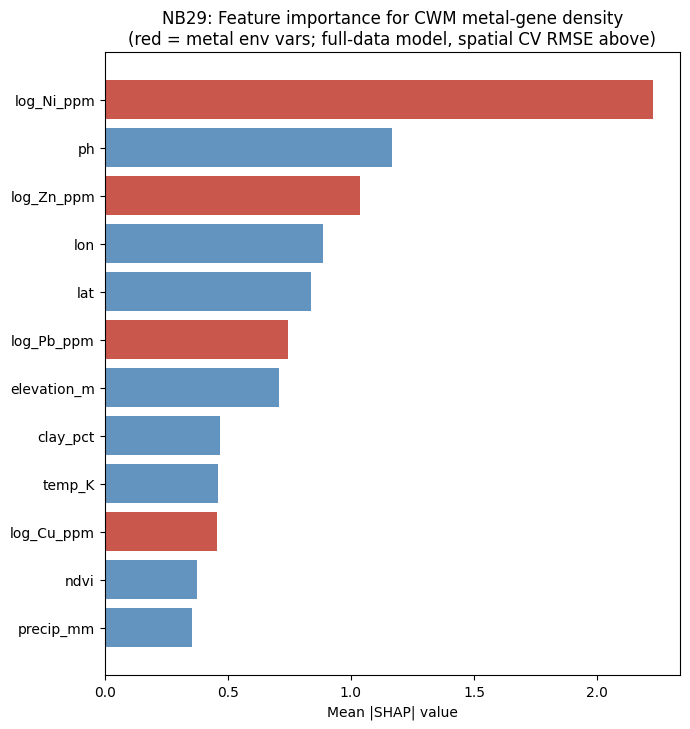

Saved nb29_cwm_from_env_shap.png

Metal features share of total mean |SHAP|: 45.9%
Top predictor: log_Ni_ppm (mean |SHAP|=2.2253)

Mean spatial block CV RMSE: 11.8909
[EXPLORATORY: not pre-registered.]


In [4]:
# SHAP feature importance: train on full data, then explain
import shap

final_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8, random_state=42)
valid_all = ~y.isna() & ~X[feature_cols].isna().any(axis=1)
final_model.fit(X[valid_all][feature_cols], y[valid_all])

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X[valid_all][feature_cols])

# Mean absolute SHAP per feature
mean_shap = pd.Series(
    abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=True)

# Color: metal vs non-metal
metal_preds = ['log_Cu_ppm', 'log_Zn_ppm', 'log_Pb_ppm', 'log_Ni_ppm']
colors = ['#c0392b' if f in metal_preds else 'steelblue' for f in mean_shap.index]

fig, ax = plt.subplots(figsize=(7, 0.45 * len(mean_shap) + 2))
ax.barh(range(len(mean_shap)), mean_shap.values, color=colors, alpha=0.85)
ax.set_yticks(range(len(mean_shap)))
ax.set_yticklabels(mean_shap.index)
ax.set_xlabel('Mean |SHAP| value')
ax.set_title('NB29: Feature importance for CWM metal-gene density\n'
             '(red = metal env vars; full-data model, spatial CV RMSE above)')
plt.tight_layout()
plt.savefig(FIGS / 'nb29_cwm_from_env_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved nb29_cwm_from_env_shap.png')

# Summary
metal_shap = mean_shap[[f for f in mean_shap.index if f in metal_preds]].sum()
total_shap = mean_shap.sum()
print(f'\nMetal features share of total mean |SHAP|: {metal_shap/total_shap*100:.1f}%')
print(f'Top predictor: {mean_shap.idxmax()} (mean |SHAP|={mean_shap.max():.4f})')
print(f'\nMean spatial block CV RMSE: {cv_df["rmse"].mean():.4f}')
print('[EXPLORATORY: not pre-registered.]')
